In [1]:
# Installs the correct modules to a users system using magic

%pip install -q pandas
%pip install -q matplotlib
%pip install -q scikit-learn
%pip install ipywidgets


# Required Packages
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
import ipywidgets as widgets
from IPython.display import display, clear_output


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# PREPARE THE DATA:
# ---------------------------------------------------------

# Gather all json in the directory and concatenate into a dataframe
paths = [
    "./Data/", # Combined Data
    "./Data/Luna - Spotify Streaming History", # 1
    "./Data/Kit - Spotify Streaming History", # 2
    "./Data/Madison - Spotify Streaming History", # 3
    "./Data/Savannah - Spotify Streaming History", # 4
    "./Data/Ari - Spotify Streaming History" # 5

]
dataset = 5 # Use the index of the dataset you want to use
folder_path = paths[dataset]

# Collect data files
# json_files = [f for f in os.listdir(folder_path) if f.endswith(".json")]
json_files = []

for root, dirs, files in os.walk(folder_path):
    for f in files:
        if f.endswith(".json"):
            full_path = os.path.join(root, f)
            json_files.append(full_path)


# Add all .json files to a DataFrame
df_list = []
for file_path in json_files:
    df_list.append(pd.read_json(file_path))


df = pd.concat(df_list, ignore_index=True)

df = df.reset_index()
# Drop unused columns
df = df.drop(
    [
        "audiobook_uri",
        "audiobook_title",
        "spotify_track_uri",
        "ip_addr",
        "platform",
        "conn_country",
        "index",
        "episode_name",
        "episode_show_name",
        "spotify_episode_uri",
        "audiobook_chapter_uri",
        "audiobook_chapter_title",
        "offline_timestamp",
        "incognito_mode",
        # "offline",
    ],
    axis=1,
)


# Convert string to datetime
df["ts"] = pd.to_datetime(df["ts"], utc=True).dt.tz_convert("America/New_York")
# Sort values and reset index
df = df.sort_values(by="ts")
df.shape

(88367, 10)

In [3]:
# Track Listen Counter
def track_counts(df, start_date="1000-01-01", end_date="9999-12-31", ascending=False):
    return (
        df[
            (df["ts"] >= min(start_date, end_date))
            & (df["ts"] < max(start_date, end_date))
        ]["master_metadata_track_name"]
        .value_counts()
        .sort_values(ascending=ascending)
    )


# Album Listen Counter
def album_counts(df, start_date="1000-01-01", end_date="9999-12-31", ascending=False):
    return (
        df[
            (df["ts"] >= min(start_date, end_date))
            & (df["ts"] < max(start_date, end_date))
        ]["master_metadata_album_album_name"]
        .value_counts()
        .sort_values(ascending=ascending)
    )


# Artist Listen Counter
def artist_counts(df, start_date="1000-01-01", end_date="9999-12-31", ascending=False):
    return (
        df[
            (df["ts"] >= min(start_date, end_date))
            & (df["ts"] < max(start_date, end_date))
        ]["master_metadata_album_artist_name"]
        .value_counts()
        .sort_values(ascending=ascending)
    )


In [4]:
# Printing results of listening counts
def print_listening_counts():
    print("Track Listen Counts:\n", track_counts(df).head(), "\n\n\n")
    print("Artist Listen Counts:\n", artist_counts(df).head(), "\n\n\n")
    print("Album Listen Counts:\n", album_counts(df).head(), "\n\n\n")
print_listening_counts()

Track Listen Counts:
 master_metadata_track_name
I Wanna Be a Boy    385
Freaks              362
Getting Used To     331
golden hour         316
Loverboy            315
Name: count, dtype: int64 



Artist Listen Counts:
 master_metadata_album_artist_name
Addison Grace     3398
girl in red       2640
Cavetown          1796
Olivia Rodrigo    1765
Ado               1697
Name: count, dtype: int64 



Album Listen Counts:
 master_metadata_album_album_name
SOUR                                       1637
Planet Her                                  777
if i could make it go quiet                 731
UTA'S SONGS ONE PIECE FILM RED              728
this is what ____ feels like (Vol. 1-4)     685
Name: count, dtype: int64 





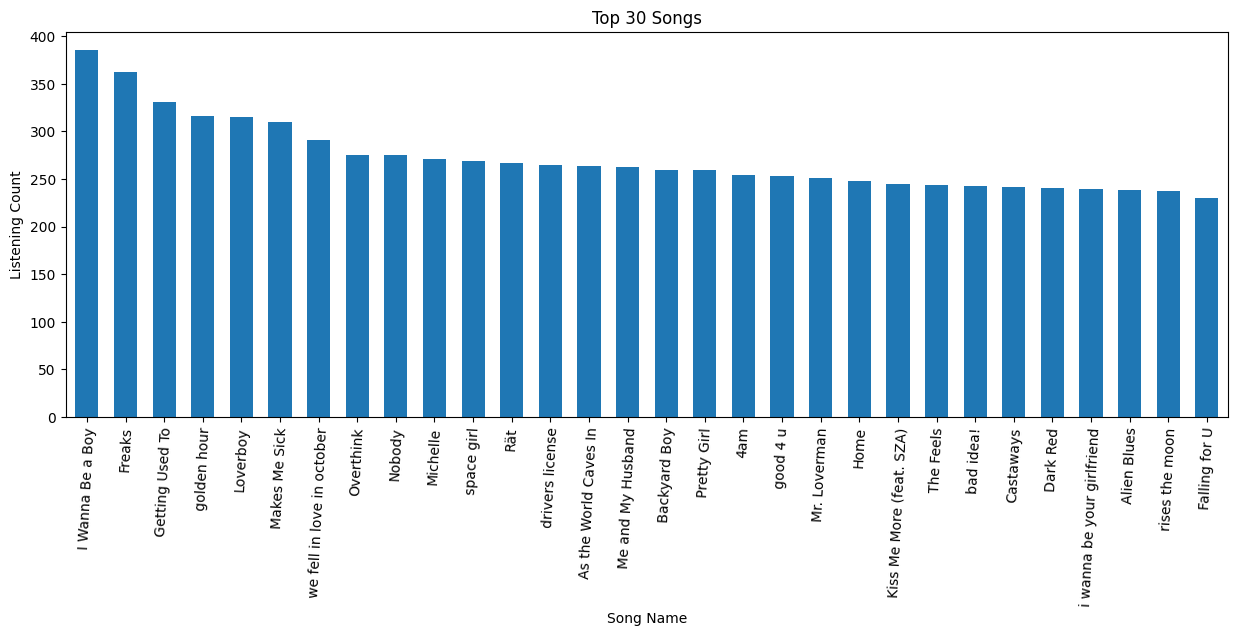

In [ ]:
# Creates a bar graph of a user's top 30 tracks

song_counts = track_counts(df)

song_counts[:30].plot.bar(width=0.6, figsize=(15, 5), rot=87)
plt.title("Top 30 Songs")
plt.xlabel("Song Name")
plt.ylabel("Listening Count")
plt.savefig("Top 30 Songs")
plt.show()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'Mayonaka no Door~stay with me'),
  Text(1, 0, 'Monster (Dotexe Remix)'),
  Text(2, 0, 'INERTIA'),
  Text(3, 0, '花傘'),
  Text(4, 0, 'Pretty Old Man'),
  Text(5, 0, 'いつも雨'),
  Text(6, 0, '忘れっぽい天使'),
  Text(7, 0, '見せかけのラブソング'),
  Text(8, 0, 'システム'),
  Text(9, 0, 'F-L-Y (Night Tempo Showa Groove Mix)'),
  Text(10, 0, 'Eureka'),
  Text(11, 0, 'Running Away'),
  Text(12, 0, 'Jump in the Line / Dead Mom - Reprise'),
  Text(13, 0, 'Kiss My Troubles Away'),
  Text(14, 0, 'Stateside + Zara Larsson'),
  Text(15, 0, 'ワタシ'),
  Text(16, 0, 'Magical'),
  Text(17, 0, 'overwhelmed - Chri$tian Gate$ remix'),
  Text(18, 0, 'OVER MY HEAD'),
  Text(19, 0, '光の方へ'),
  Text(20, 0, 'TELECASTER STRIPE'),
  Text(21, 0, 'Kekka Orai(English ver)'),
  Text(22, 0, 'Pain Give Form'),
  Text(23, 0, 'Keeper'),
  Text(24, 0, 'Watch me!'),

/Users/lunadesroches/Documents/School/DATASCI/Project/Music-Data-Project/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 33457 (\N{CJK UNIFIED IDEOGRAPH-82B1}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/lunadesroches/Documents/School/DATASCI/Project/Music-Data-Project/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 20632 (\N{CJK UNIFIED IDEOGRAPH-5098}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/lunadesroches/Documents/School/DATASCI/Project/Music-Data-Project/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/lunadesroches/Documents/School/DATASCI/Project/Music-Data-Project/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 12388 (\N{HIRAGANA LETTER TU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/lu

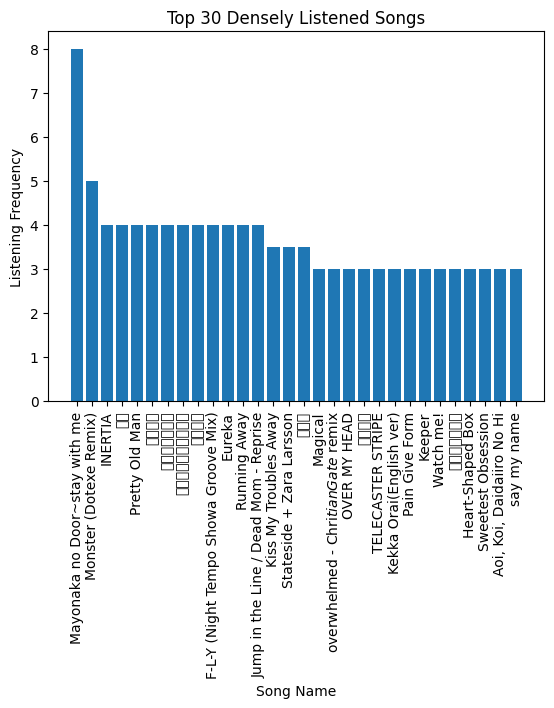

In [6]:
# Group and compute time span
grouped = df.groupby('master_metadata_track_name')['ts'].agg(['min', 'max'])
grouped['time_span'] = (grouped['max'] - grouped['min']).dt.days
grouped = grouped[grouped["time_span"] > 0]
grouped = grouped.reset_index()

# Convert counts to DataFrame
song_counts = df['master_metadata_track_name'].value_counts().reset_index()
song_counts.columns = ['master_metadata_track_name', 'count']

# Merge
merged = song_counts.merge(grouped, on='master_metadata_track_name')
merged['playing_frequency'] = merged['count'] / merged['time_span']
merged = merged.sort_values(by='playing_frequency', ascending=False)

#Graph Creation
plt.bar(merged['master_metadata_track_name'][:30], merged['playing_frequency'][:30])
plt.title("Top 30 Densely Listened Songs")
plt.xlabel("Song Name")
plt.ylabel("Listening Frequency")
plt.xticks(rotation='vertical')

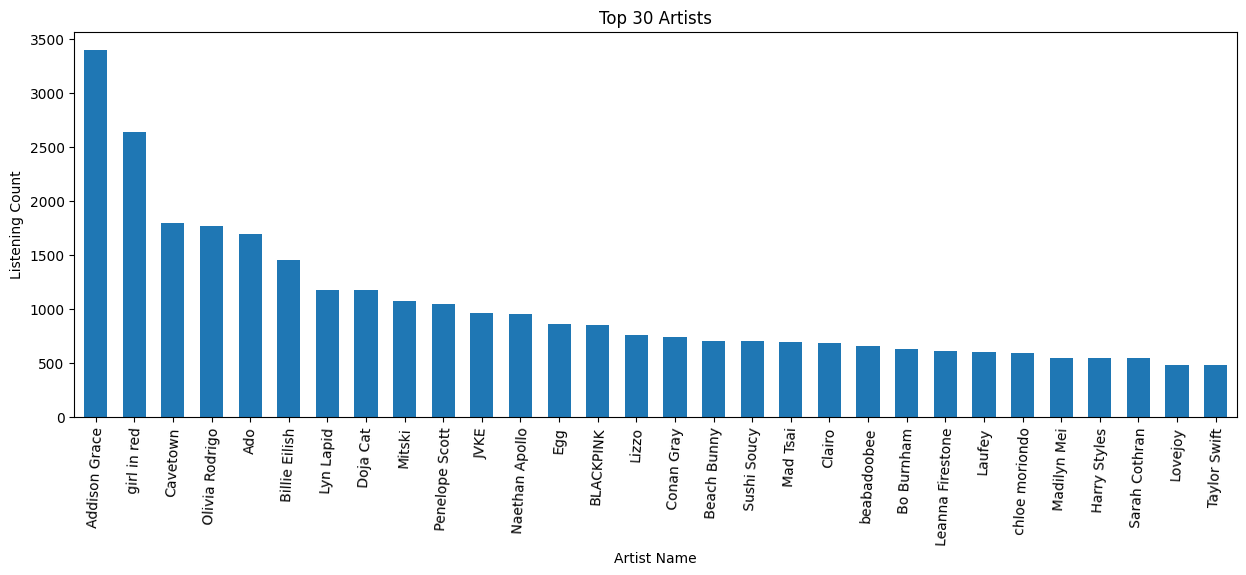

In [7]:
# Creates a bar graph of a user's top 30 artists

artist_tally = artist_counts(df)

artist_tally[:30].plot.bar(width=0.6, figsize=(15, 5), rot=87)
plt.title("Top 30 Artists")
plt.xlabel("Artist Name")
plt.ylabel("Listening Count")
plt.savefig("TopArtists.png", bbox_inches="tight")

Text(0.5, 1.0, 'Songs Listened to by Hour of Day')

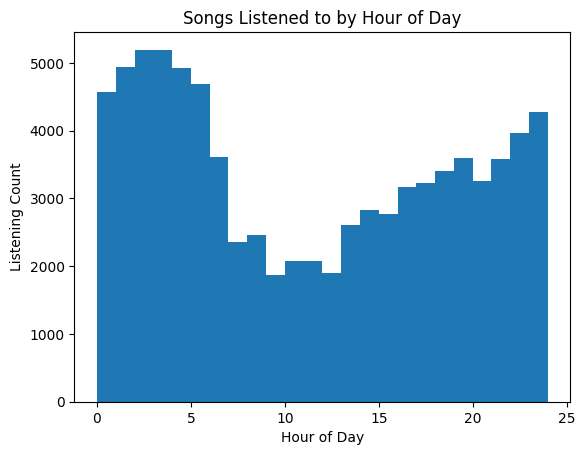

In [8]:
# Creates a histogram of the most frequent listening time in the dataset

time_set = df[(df["ts"] >= "01-01-2000") & (df["ts"] < "01-01-2026")]["ts"].dt.hour

plt.hist(time_set, bins=24, range=(0, 24))
plt.xlabel("Hour of Day")
plt.ylabel("Listening Count")
plt.title("Songs Listened to by Hour of Day")

In [ ]:
# Creates DataFrame to calculate skip rate for songs

skipped = (
    df[df["skipped"]]["master_metadata_track_name"]
    .value_counts()
    .sort_values(ascending=False)
)
song_counts = track_counts(df)

track_stats = pd.DataFrame({"total_listens": song_counts, "skips": skipped})
# track_stats['skips'] = track_stats['skips'].fillna(0)

# Filters tracks with at least 10 listens
track_stats_filtered = track_stats[track_stats["total_listens"] >= 10]

# Calculates skips/total_listens to get skip rates
track_stats_filtered["skip_rate"] = (
    track_stats_filtered["skips"] / track_stats_filtered["total_listens"]
)

# Sort by skip rate
track_stats = track_stats_filtered.sort_values(by="skip_rate", ascending=False)

# Map artists to song
artist_map = df.drop_duplicates(subset=["master_metadata_track_name"]).set_index(
    "master_metadata_track_name"
)["master_metadata_album_artist_name"]
track_stats["artist"] = track_stats.index.map(artist_map)

# Set df index
track_stats.index.name = "track_name"
track_stats_final = track_stats.reset_index()

track_stats_final = track_stats_final[
    ["track_name", "artist", "total_listens", "skips", "skip_rate"]
]
# track_stats_final[:30]

,track_name,artist,total_listens,skips,skip_rate
0,Washington on Your Side,Leslie Odom Jr.,11,7.0,0.636364
1,Say No to This,Jasmine Cephas-Jones,10,6.0,0.600000
2,Cabinet Battle #1,Christopher Jackson,12,7.0,0.583333
3,"Sincerely, Me",Mike Faist,18,10.0,0.555556
4,"사랑인가 봐 Love, Maybe",MeloMance,10,5.0,0.500000
5,A Million Miles Away,Belle,10,5.0,0.500000
6,Starships,Nicki Minaj,10,5.0,0.500000
7,Hurricane,Bridgit Mendler,10,5.0,0.500000
8,Seventeen Brainrot - We're Beta,Tambo,10,5.0,0.500000
9,I Know Him,Jonathan Groff,10,5.0,0.500000


/var/folders/b_/025cj8kj7w1g7synd135gm0m0000gn/T/ipykernel_27706/2493326334.py:6: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.savefig("TopSkipped.png", bbox_inches="tight")
/var/folders/b_/025cj8kj7w1g7synd135gm0m0000gn/T/ipykernel_27706/2493326334.py:6: UserWarning: Glyph 46993 (\N{HANGUL SYLLABLE RANG}) missing from font(s) DejaVu Sans.
  plt.savefig("TopSkipped.png", bbox_inches="tight")
/var/folders/b_/025cj8kj7w1g7synd135gm0m0000gn/T/ipykernel_27706/2493326334.py:6: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.savefig("TopSkipped.png", bbox_inches="tight")
/var/folders/b_/025cj8kj7w1g7synd135gm0m0000gn/T/ipykernel_27706/2493326334.py:6: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.savefig("TopSkipped.png", bbox_inches="tight")
/var/folders/b_/025cj8kj7w1g7synd135gm0m0000gn/T/ipykernel_27706/2493326334.py:6: UserWarning: Glyph 48400 (\N{HANGUL SYLL

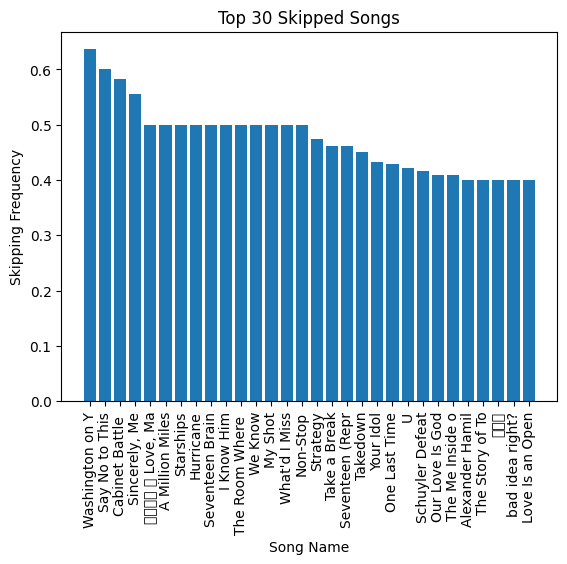

In [10]:
plt.bar([label[:15] for label in track_stats_final['track_name'][:30]], track_stats_final['skip_rate'][:30])
plt.title("Top 30 Skipped Songs")
plt.xlabel("Song Name")
plt.ylabel("Skipping Frequency")
plt.xticks(rotation='vertical')
plt.savefig("TopSkipped.png", bbox_inches="tight")

In [11]:
# Good idea to only use with one users data, it's pretty hard to predict 3 completely different people

# Used 3 different steps to predict a users skip rate

# 1. ORGANIZE THE DATA
# ---------------------------------------------------------
# Copy over the data to a new df
ml_df = df.dropna(
    subset=["skipped", "reason_start", "master_metadata_track_name"]
).copy()

# Map the calculated skip rate for each song to the DataFrame
ml_df["historical_skip_rate"] = (
    ml_df["master_metadata_track_name"].map(track_stats["skip_rate"]).fillna(0)
)

# Convert 'reason_start' to dummy variables
ml_df = pd.get_dummies(ml_df, columns=["reason_start"], drop_first=True)

# Define our Features (X) and our Target (y)
# Set our features to reason_start and our target to historical_skip_rate
feature_cols = ["historical_skip_rate"] + [
    col for col in ml_df.columns if "reason_start_" in col
]
X = ml_df[feature_cols]

# 1 if Skipped, 0 if Not Skipped
y = ml_df["skipped"].astype(int)


# 2. SPLIT DATA
# ---------------------------------------------------------
# Split the X and y data between training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 3. TRAINING
# ---------------------------------------------------------
# Use RandomForestClassifier to create our model
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=20)

# Train the model on your data
rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)

# Determine the accuracy of our predicted values
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Determine which feature influenced our predictions the most
feature_importances = pd.DataFrame(
    {"Feature": X.columns, "Importance": rf_model.feature_importances_}
).sort_values(by="Importance", ascending=False)

print("What drives your skips?")
print(feature_importances)

Model Accuracy: 94.79%

What drives your skips?
                   Feature  Importance
7   reason_start_trackdone    0.392201
0     historical_skip_rate    0.297256
2    reason_start_clickrow    0.158638
3      reason_start_fwdbtn    0.088892
1     reason_start_backbtn    0.030063
9     reason_start_unknown    0.015830
4     reason_start_playbtn    0.009711
8  reason_start_trackerror    0.004912
6      reason_start_remote    0.002139
5   reason_start_reconnect    0.000357


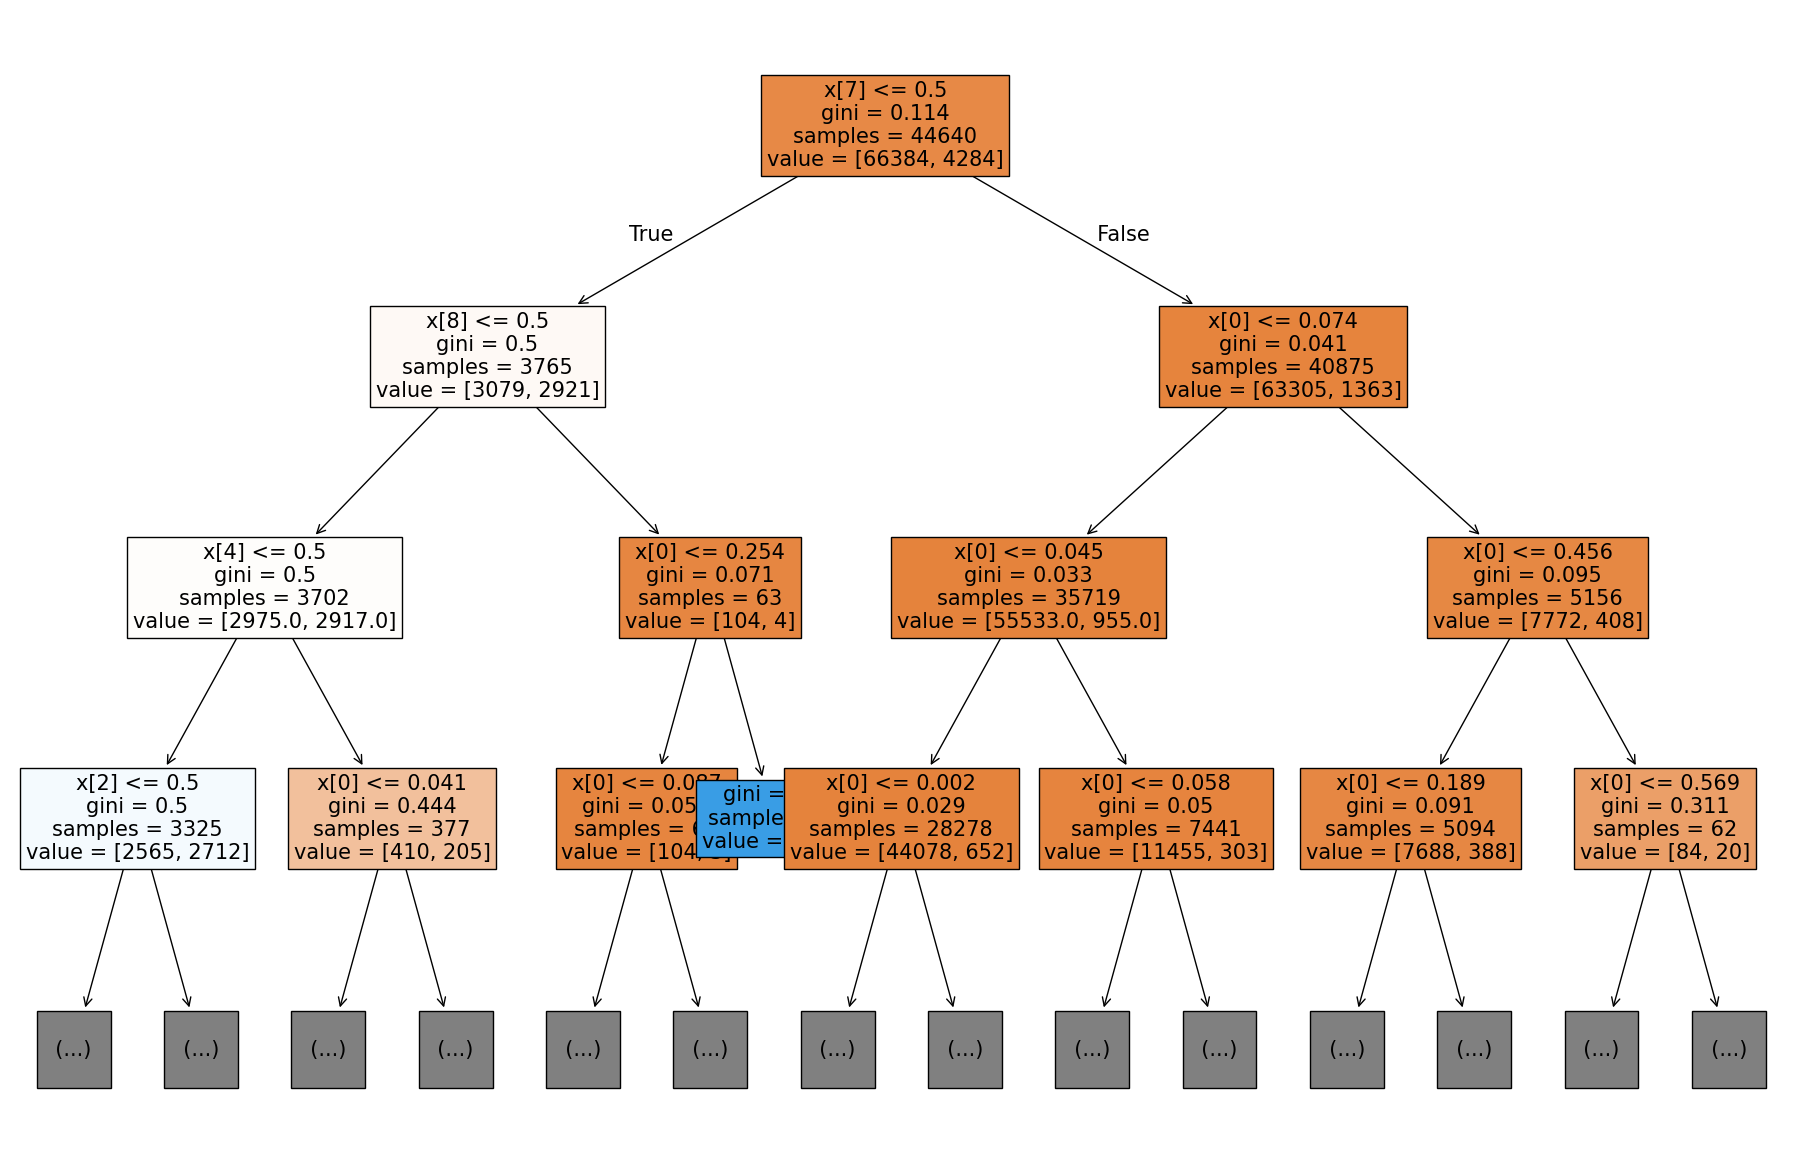

In [12]:
clf_0 = rf_model.estimators_[0]

plt.figure(figsize=(23, 15))
tree_plot_0 = tree.plot_tree(clf_0, fontsize=15, filled=True, max_depth=3)
plt.show()

In [13]:
# Data to select from
unique_songs = track_stats_final["track_name"].dropna().unique()
start_reasons = [
    col.replace("reason_start_", "") for col in feature_cols if "reason_start_" in col
]

# Interactive Dropdowns to select song and start reason
song_dropdown = widgets.Dropdown(
    options=unique_songs,
    description="Song:",
    style={"description_width": "initial"},
    layout={"width": "max-content"},
)

reason_dropdown = widgets.Dropdown(
    options=start_reasons,
    description="Start Reason:",
    style={"description_width": "initial"},
    layout={"width": "max-content"},
)

out = widgets.Output()


def predict_real_time(change):
    with out:
        # Clear the old prediction
        clear_output()

        selected_song = song_dropdown.value
        selected_reason = reason_dropdown.value

        # Determine historical skip rate for the selected song
        song_data = track_stats_final[track_stats_final["track_name"] == selected_song]
        if not song_data.empty:
            skip_rate = song_data["skip_rate"].values[0]
        else:
            skip_rate = 0.0

        # Basic structure of the DataFrame the model uses
        new_song_data = {
            "historical_skip_rate": [skip_rate],
            f"reason_start_{selected_reason}": [1],
        }

        new_song_df = pd.DataFrame(new_song_data)
        new_song_df = new_song_df.reindex(columns=X.columns, fill_value=0)

        # Generate the prediction
        probabilities = rf_model.predict_proba(new_song_df)
        skip_probability = probabilities[0][1]

        # Display the UI
        print(f"\nSong to Analyze: {selected_song}")
        print(f"Historical Skip Rate: {skip_rate * 100:.1f}%")
        print(f"Start Reason: '{selected_reason}'\n")

        print("Verdict:", "Skipped" if skip_probability > 0.5 else "Played")

        print(f"Skip Confidence: {skip_probability * 100:.1f}%")


# Link the dropdowns to the function to update automatically
song_dropdown.observe(predict_real_time, names="value")
reason_dropdown.observe(predict_real_time, names="value")

# Display and run to initialize
display(song_dropdown, reason_dropdown, out)
predict_real_time(None)

Dropdown(description='Song:', layout=Layout(width='max-content'), options=('Washington on Your Side', 'Say No …

Dropdown(description='Start Reason:', layout=Layout(width='max-content'), options=('backbtn', 'clickrow', 'fwd…

Output()

In [14]:
i = 0
j = 0
for row in df['offline']:
    if row:
        i += 1
    else:
        j += 1
print(i, j)

1517 86850
